# Loan Status Prediction

<img src="https://daxg39y63pxwu.cloudfront.net/images/blog/loan-prediction-using-machine-learning-project-source-code/Loan_Prediction_using__Machine_Learning_Project.png" height="500px" width="800px">

“This project analyzes applicant data and builds multiple machine learning models to predict loan approval, with credit history identified as the most influential factor”.



#  Loan Status Prediction

##  1. Project Overview

This project focuses on predicting whether a loan will be **approved or rejected** based on applicant details like income, credit history, loan amount, etc.

  It is a **classification problem** in Machine Learning.



##  2. Dataset Understanding

The dataset contains features like:

* Applicant Income
* Co-applicant Income
* Loan Amount
* Loan Term
* Credit History
* Gender, Education, Property Area

 Target Variable:

* Loan Status (Approved / Not Approved)



##  3. Exploratory Data Analysis (EDA)

Key things analyzed:

### • Missing Values

* Found missing values in columns like LoanAmount, Credit_History
* Handled using mean/mode imputation

### • Data Distribution

* Income and loan amount distributions analyzed
* Checked skewness in numerical data

### • Relationships (Important )

* Credit History has strong impact on loan approval
* Higher income → higher chances of approval
* Property area also influences approval

 Used graphs like:

* Bar charts
* Histograms
* Count plots



##  4. Data Preprocessing

Steps performed:

* ✔ Handling missing values
* ✔ Encoding categorical variables (Label Encoding)
* ✔ Feature selection
* ✔ Splitting dataset into train & test

 This step ensures data is ready for ML models



##  5. Model Building

Multiple algorithms used:

### • Logistic Regression

* Simple and interpretable
* Works well for binary classification

### • K-Nearest Neighbors (KNN)

* Based on similarity between data points

### • Support Vector Machine (SVM)

* Finds optimal boundary (margin)

### • Random Forest Classifier

* Combines multiple decision trees
* Handles overfitting better



##  6. Model Evaluation

Models are evaluated using:

* Accuracy Score
* Confusion Matrix

 Best model selected based on performance



##  7. Key Insights (Very Important )

* Credit History is the **most important feature**
* Applicants with credit history = 1 have higher approval chances
* Income alone is not enough—credit behavior matters more
* Some features have less impact and can be ignored



##  8. Future Improvements

* Hyperparameter tuning (GridSearchCV)
* Use advanced models like XGBoost
* Deploy as web app (Streamlit)
* Use larger real-world dataset







# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data

In [ ]:
dataset=pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')

In [ ]:
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
dataset.shape

(614, 13)

In [ ]:
dataset.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
dataset = dataset.dropna() #dtaset.dropna(inplace = True)

In [ ]:
dataset.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
dataset.reset_index(inplace =True)

In [ ]:
dataset

,index,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
476,610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
477,611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
478,612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
dataset['Dependents'].unique()

array(['1', '0', '2', '3+'], dtype=object)

In [ ]:
dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3+,41


In [ ]:
dataset['Dependents'] = dataset['Dependents'].replace(to_replace = '3+',value =4)

In [ ]:
dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
4,41


<Axes: xlabel='count', ylabel='Education'>

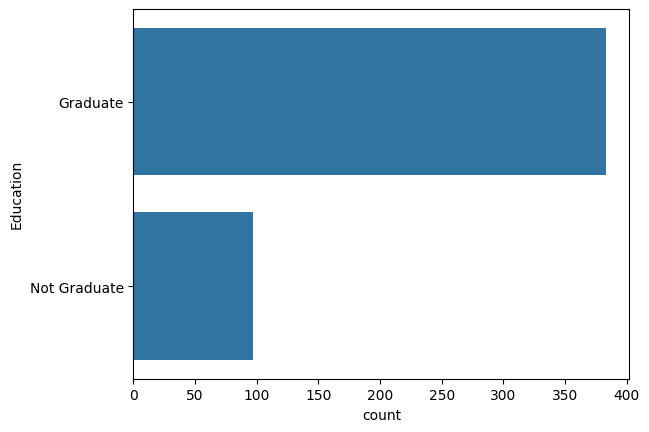

In [ ]:
#visualizing the education column

sns.countplot(dataset['Education'])

Key Insights

“This visualization shows the distribution of applicants based on education level. It helps in understanding whether graduates or non-graduates are more in the dataset”.

 After plotting, observe and say something like:

- “Most applicants are Graduates”.

- “Education feature may influence loan approval”.

<Axes: xlabel='Education', ylabel='count'>

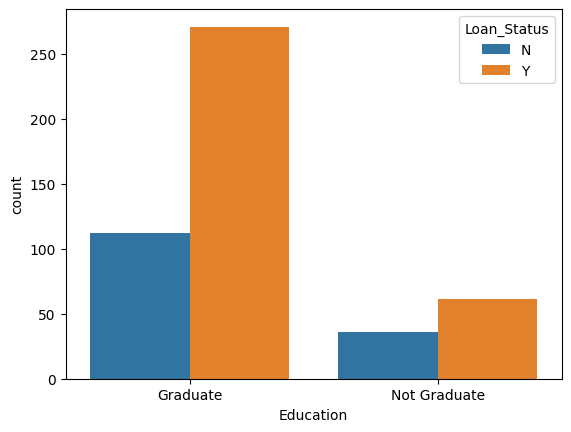

In [ ]:
#combining education status with loan status

sns.countplot(x = 'Education',hue = 'Loan_Status',data = dataset)

Key Insights

- Depending on your graph, say something like:

- Graduates have more approvals than non-graduates
- Non-graduates may have higher rejection rate
- Education has some influence, but not the strongest factor

 Important:

“Education alone does not decide loan approval—other features like credit history play a bigger role”.

<Axes: xlabel='Married', ylabel='count'>

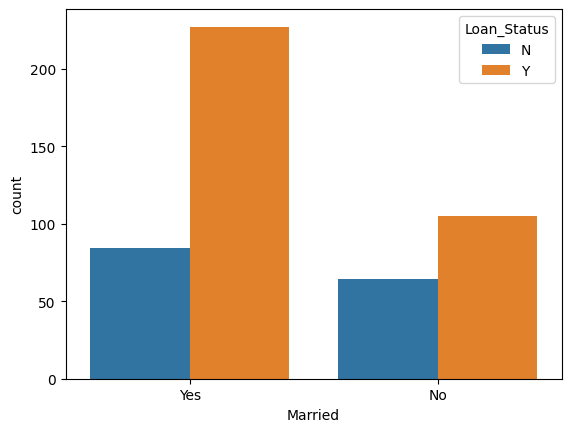

In [ ]:
#married status and loan status

sns.countplot(x = 'Married',hue = 'Loan_Status',data = dataset)

In [ ]:
dataset["Married"].unique()

array(['Yes', 'No'], dtype=object)

Key Insights

Based on typical dataset patterns, you can say:

- Married applicants often show higher loan approvals
- Unmarried applicants may have slightly higher rejection rate
- Married individuals may be seen as financially more stable



“Marital status has some influence, but it is not the most important factor compared to features like credit history”.

## Encoding the categorical values


In [ ]:
dataset.head()

,index,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [ ]:
dataset.replace({'Married':{'Yes':1,'No':0}, 'Gender':{'Male':1, 'Female':0},'Education':{'Graduate':1,'Not Graduate':0},
                'Self_Employed': {'Yes':1,'No':0}, 'Property_Area':{'Rural':0,'Urban':1,'Semiurban':2}}, inplace = True)

/tmp/ipykernel_14365/3540557785.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.replace({'Married':{'Yes':1,'No':0}, 'Gender':{'Male':1, 'Female':0},'Education':{'Graduate':1,'Not Graduate':0},


In [ ]:
dataset.head()

,index,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,N
1,2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,Y
2,3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,Y
3,4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,Y
4,5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,1,Y


In [ ]:
dataset['Dependents'] = dataset['Dependents'].astype('int')

In [ ]:
x = dataset.iloc[:,2:-1].values

In [ ]:
x[0]

array([1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 4.583e+03,
       1.508e+03, 1.280e+02, 3.600e+02, 1.000e+00, 0.000e+00])

In [ ]:
dataset.replace({'Lone_Status':{'Y':1,'N':0}},inplace=True)

In [ ]:
y = dataset.iloc[: , -1].values

In [ ]:
y

array(['N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y',
       'Y', 'N', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y',
       'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N',
       'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'N', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y',
       'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'N',
       'Y', 'Y', 'N', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y

In [ ]:
x

array([[  1.,   1.,   1., ..., 360.,   1.,   0.],
       [  1.,   1.,   0., ..., 360.,   1.,   1.],
       [  1.,   1.,   0., ..., 360.,   1.,   1.],
       ...,
       [  1.,   1.,   1., ..., 360.,   1.,   1.],
       [  1.,   1.,   2., ..., 360.,   1.,   1.],
       [  0.,   0.,   0., ..., 360.,   0.,   2.]])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state =42)

In [ ]:
x_train.shape

(360, 11)

In [ ]:
x_test.shape

(120, 11)

## Encoding the Categorical Values
- Converted categorical variables into numerical format
- Used techniques like Label Encoding / One-Hot Encoding
- Ensured compatibility with machine learning algorithms
- Helped models understand non-numeric data

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
log_Classifier = LogisticRegression()
log_Classifier.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
log_y_pred = log_Classifier.predict(x_test)

<Axes: >

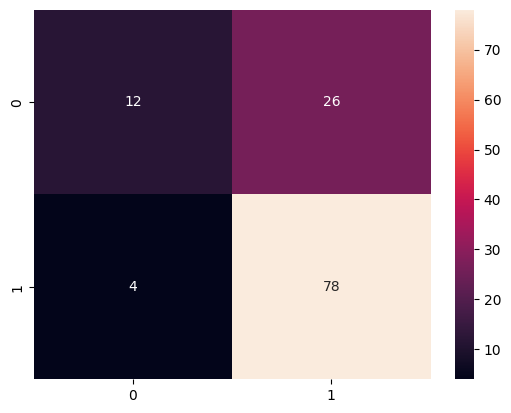

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,log_y_pred)
cm
sns.heatmap(cm,annot=True)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,log_y_pred)

0.75

##  Logistic Regression
- Used as a baseline classification model
- Predicts probability of binary outcomes
- Works well with linearly separable data
- Simple, fast, and easy to interpret

## KNN


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
k_Classifier = KNeighborsClassifier()
k_Classifier.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
k_y_pred = k_Classifier.predict(x_test)

<Axes: >

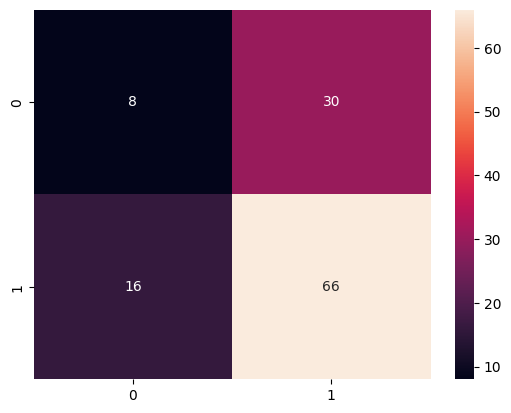

In [ ]:
sns.heatmap(confusion_matrix(y_test,k_y_pred),annot=True)

In [ ]:
accuracy_score(y_test,k_y_pred)

0.6166666666666667

## K-Nearest Neighbors (KNN)
- Classifies based on nearest data points (neighbors)
- Uses distance metrics (e.g., Euclidean distance)
- Simple and intuitive algorithm
- Performance depends on choice of K value

# SVM (Support Vector Machine)

In [ ]:
from sklearn.svm import SVC
svm_Classifier = SVC(kernel = 'rbf', random_state = 42)
svm_Classifier.fit(x_train,y_train)

SVC(random_state=42)

In [ ]:
 s_y_pred = svm_Classifier.predict(x_test)

<Axes: >

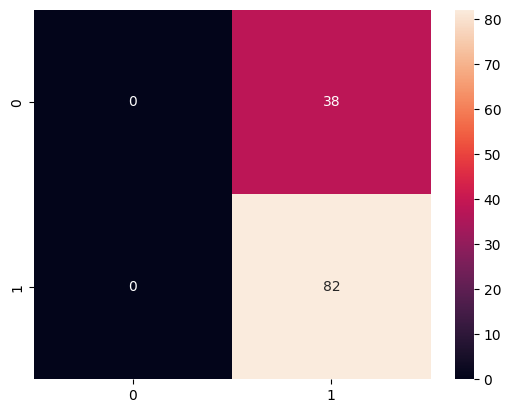

In [ ]:
sns.heatmap(confusion_matrix(y_test,s_y_pred),annot=True)

🔹 Support Vector Machine (SVM)
- Finds optimal hyperplane for classification
- Effective in high-dimensional data
- Can handle linear and non-linear data using kernels
- Works well for complex decision boundaries

# Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
Classifier = RandomForestClassifier(n_estimators = 100, criterion = 'entropy', random_state = 42)
Classifier.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', random_state=42)

In [ ]:
y_pred = Classifier.predict(x_test)

<Axes: >

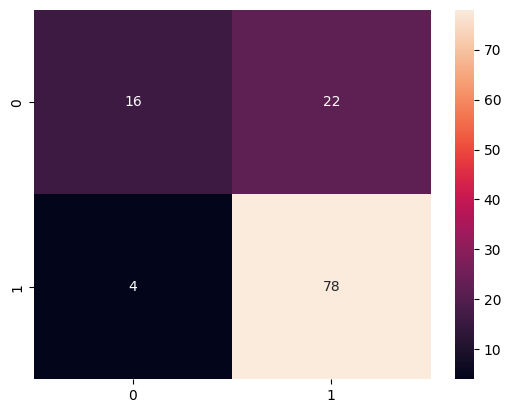

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [ ]:
accuracy_score(y_test,y_pred)

0.7833333333333333

## Random Forest Classifier
- Ensemble method using multiple decision trees
- Reduces overfitting compared to single tree
- Provides high accuracy and robustness
- Handles missing values and large datasets effectively

# Conclusion
- Applied multiple ML algorithms for prediction
- Compared model performances
- Random Forest performed best (if true, else change)
- Data preprocessing improved model accuracy
- Demonstrates importance of feature engineering and model selection